In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

#write the code to upload file
uploaded = files.upload()

Saving Outing Preferences Survey (Responses) - Form Responses 1 (1).csv to Outing Preferences Survey (Responses) - Form Responses 1 (1).csv


In [3]:
outing_data=pd.read_csv('Outing Preferences Survey (Responses) - Form Responses 1 (1).csv')
outing_data.head()

,date&time,age,gender,Places,recommendation,rate,factors,how often,when,money_spend,effect
0,4/7/2026 21:03:54,18-22,Female,Café / coffee shop,Cilantro,Fair / reasonable,Atmosphere / vibe,A few times a month,In the morning,300-500,"No, price didn’t affect my enjoyment."
1,4/7/2026 21:06:23,18-22,Female,Restaurant (fine dining),Restaurants,Slightly expensive ·,Quality of food / drinks,Once a week,In the afternoon,600-900,"No, price didn’t affect my enjoyment."
2,4/7/2026 21:07:41,18-22,Female,Café / coffee shop,Mall,Slightly expensive ·,Quality of food / drinks,A few times a week,In the afternoon,300-500,"No, price didn’t affect my enjoyment."
3,4/7/2026 21:08:22,18-22,Female,Café / coffee shop,NaN,Slightly expensive ·,Quality of food / drinks,A few times a month,In the morning,200 or less,"Yes, I enjoy it less because of cost ·"
4,4/7/2026 21:09:24,18-22,Female,Café / coffee shop,NaN,Slightly expensive ·,Atmosphere / vibe,A few times a month,In the afternoon,300-500,"No, price didn’t affect my enjoyment."


Cleaning Data

In [4]:
outing_data.isnull().sum()

,0
date&time,0
age,0
gender,0
Places,0
recommendation,31
rate,0
factors,0
how often,0
when,0
money_spend,0


In [5]:
outing_data=outing_data.drop(columns=['recommendation','date&time'] , axis=1)



In [6]:
mapping = {
    "200 or less": 200,
    "300-500": 400,
    "600-900": 750,
    "1k or more": 1000
}

outing_data["spend_numeric"] = outing_data["money_spend"].map(mapping)

In [7]:
round(outing_data["spend_numeric"].mean(),1)

np.float64(422.4)

In [8]:
outing_data["spend_numeric"].median()

400.0

In [9]:
round(outing_data["spend_numeric"].std(),1)

192.7

In [10]:
for data in outing_data:
  print(outing_data[data].mode())

0    18-22
Name: age, dtype: object
0    Female
Name: gender, dtype: object
0    Café / coffee shop
Name: Places , dtype: object
0    Fair / reasonable
Name: rate, dtype: object
0    Atmosphere / vibe
Name: factors, dtype: object
0    A few times a month
Name: how often , dtype: object
0    In the afternoon
Name: when, dtype: object
0    300-500
Name: money_spend, dtype: object
0    No, price didn’t affect my enjoyment.
Name: effect, dtype: object
0    400
Name: spend_numeric, dtype: int64


**Gender Percentage**

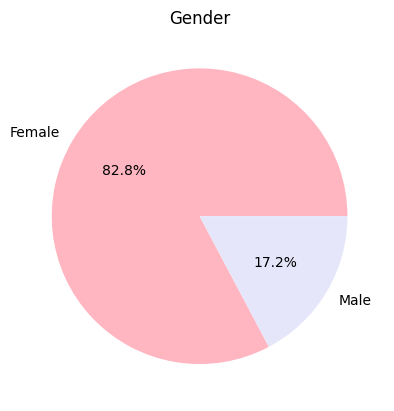

In [11]:
effects_count = outing_data['gender'].value_counts()

plt.pie(effects_count, labels=effects_count.index, autopct='%1.1f%%', colors=['lightpink', 'lavender'], startangle=0)

plt.title('Gender')

plt.show()

**Age percentage**

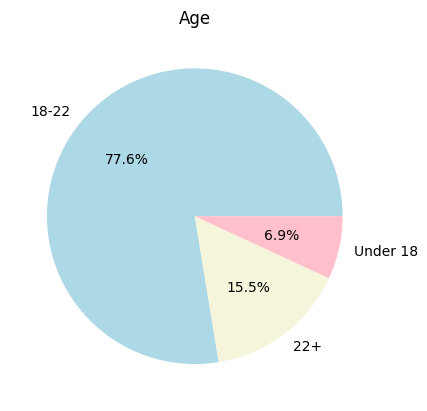

In [12]:
effects_count = outing_data['age'].value_counts()

plt.pie(effects_count, labels=effects_count.index, autopct='%1.1f%%', colors=['lightblue', 'beige','pink'], startangle=0)

plt.title('Age')

plt.show()

**Most Preferred Outing Places**

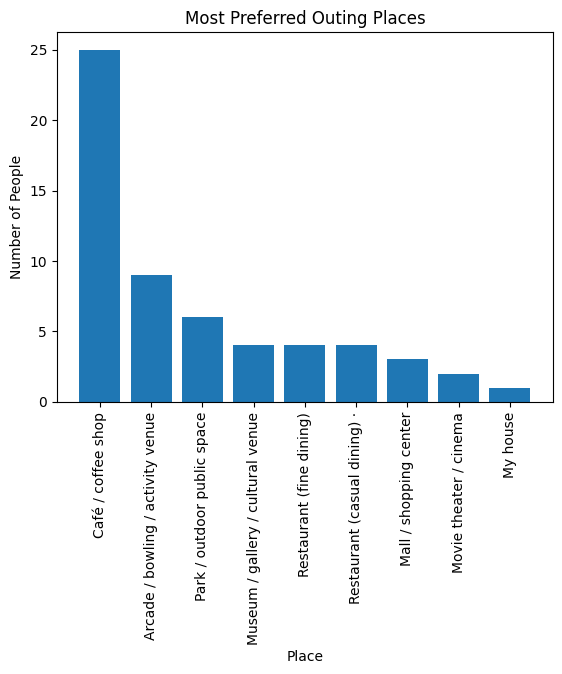

In [13]:
counts = outing_data["Places "].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Most Preferred Outing Places")
plt.xlabel("Place")
plt.ylabel("Number of People")

plt.xticks(rotation=90)  # optional (makes labels readable)

plt.show()

**Spending Range of Participants**

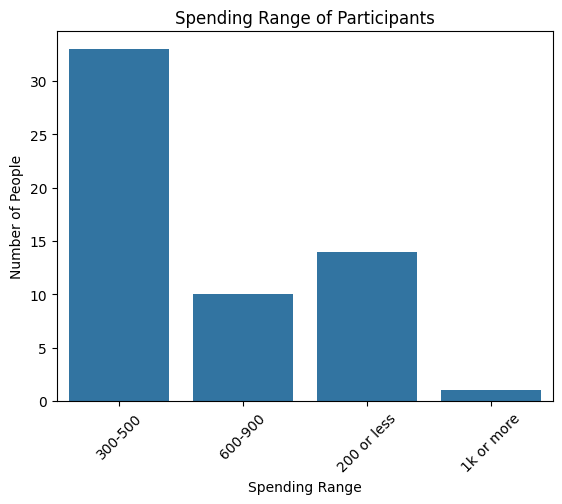

In [14]:
sns.countplot(x="money_spend", data=outing_data)

plt.title("Spending Range of Participants")
plt.xlabel("Spending Range")
plt.ylabel("Number of People")

plt.xticks(rotation=45)
plt.show()

**Spending Range Across Different Places**

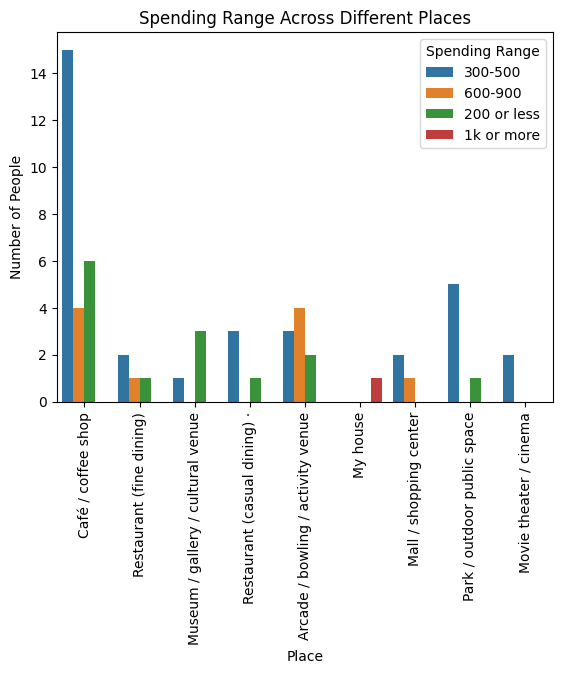

In [15]:
sns.countplot(x="Places ", hue="money_spend", data=outing_data)

plt.title("Spending Range Across Different Places")
plt.xlabel("Place")
plt.ylabel("Number of People")

plt.xticks(rotation=90)
plt.legend(title="Spending Range")

plt.show()

**Outing Preferences by Gender**

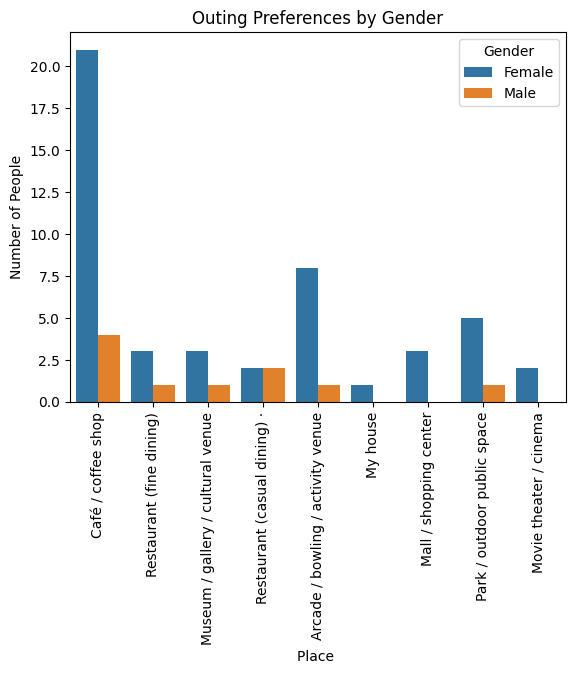

In [16]:
sns.countplot(x="Places ", hue="gender", data=outing_data)

plt.title("Outing Preferences by Gender")
plt.xlabel("Place ")
plt.ylabel("Number of People")

plt.xticks(rotation=90)
plt.legend(title="Gender")

plt.show()

**Time that people prefer to go out by Age**

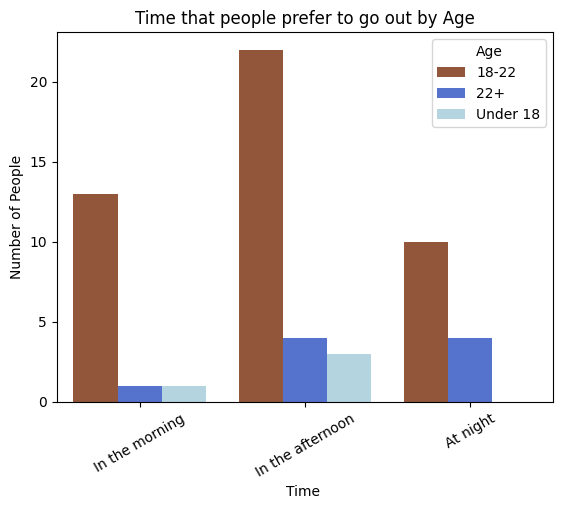

In [17]:
sns.countplot(x="when", hue="age", data= outing_data, palette=['sienna','royalblue','lightblue'])

plt.title("Time that people prefer to go out by Age")
plt.xlabel("Time ")
plt.ylabel("Number of People")

plt.xticks(rotation=30)
plt.legend(title="Age")

plt.show()

**Factors for choosing place by Age**

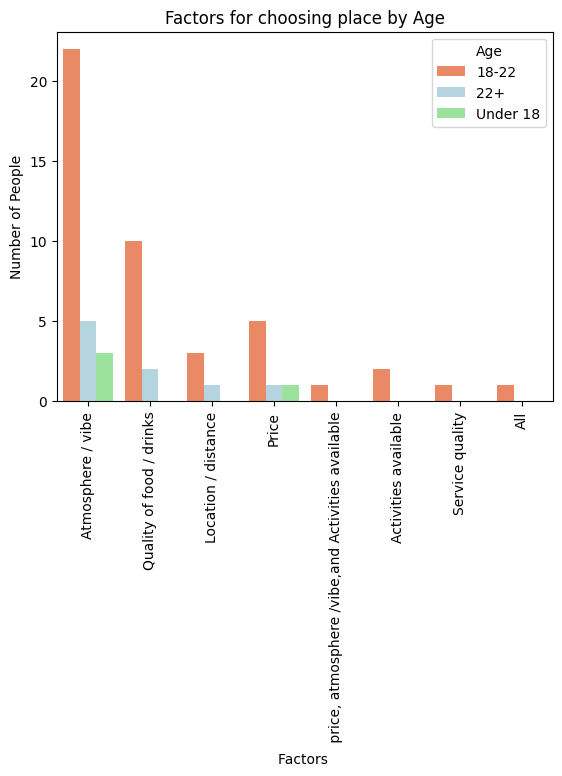

In [18]:
sns.countplot(x="factors", hue="age", data= outing_data, palette=['coral','lightblue','lightgreen'])

plt.title("Factors for choosing place by Age")
plt.xlabel("Factors ")
plt.ylabel("Number of People")

plt.xticks(rotation=90)
plt.legend(title="Age")

plt.show()

**Outing Preferences by age**

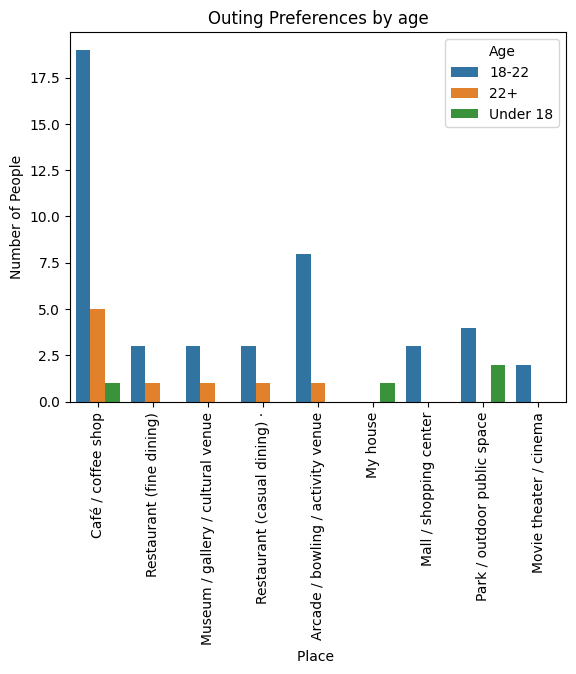

In [19]:
sns.countplot(x="Places ", hue="age", data=outing_data)

plt.title("Outing Preferences by age")
plt.xlabel("Place ")
plt.ylabel("Number of People")

plt.xticks(rotation=90)
plt.legend(title="Age")

plt.show()

**Handelling effect column**

In [20]:
outing_data['effect'].unique()

array(['No, price didn’t affect my enjoyment.',
       'Yes, I enjoy it less because of cost ·',
       'Yes, I enjoy it more because it felt worth it.',
       "It varies depending on the time and place. Sometimes money is a bit of a hindrance; for example, a place might be full of activities, but each one has its own price, and they're often very high. So sometimes we can't do everything we want because of that. Or, for example, if it's food or drinks, it's the same thing. And sometimes it doesn't matter; for example, things are reasonably priced and not so high",
       'Depending on'], dtype=object)

In [21]:
outing_data['effect'][18]='Depending on'
outing_data['effect'].unique()

/tmp/ipykernel_8610/100459636.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  outing_data['effect'][18]='Depending on'
/tmp/ipykernel_8610/100459636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

array(['No, price didn’t affect my enjoyment.',
       'Yes, I enjoy it less because of cost ·',
       'Yes, I enjoy it more because it felt worth it.', 'Depending on'],
      dtype=object)

In [22]:
outing_data['effect'].replace({'No, price didn’t affect my enjoyment.':"doesn't affect",
                              'Yes, I enjoy it less because of cost ·':"enjoy less",
                              'Yes, I enjoy it more because it felt worth it.':"enjoy more"},inplace=True)
outing_data['effect'].unique()

/tmp/ipykernel_8610/1808239632.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  outing_data['effect'].replace({'No, price didn’t affect my enjoyment.':"doesn't affect",


array(["doesn't affect", 'enjoy less', 'enjoy more', 'Depending on'],
      dtype=object)

**Spending vs Effect on Enjoyment**

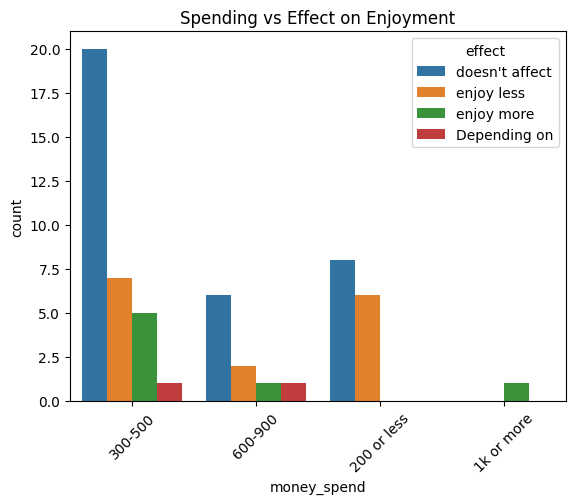

In [23]:
sns.countplot(x="money_spend", hue="effect", data=outing_data)

plt.title("Spending vs Effect on Enjoyment")
plt.xticks(rotation=45)
plt.show()

**Price Effect on Enjoyment**

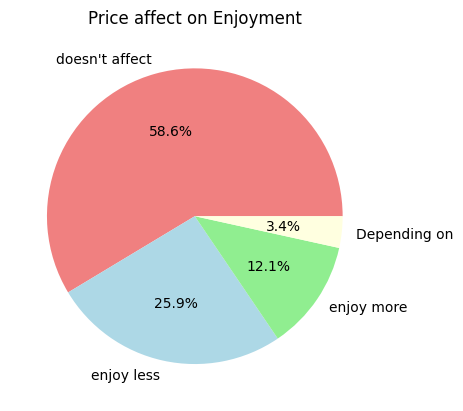

In [24]:
effects_count = outing_data['effect'].value_counts()

# 2. Create the Pie Chart
# autopct='%1.1f%%' displays the percentages on the slices
plt.pie(effects_count, labels=effects_count.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue','lightgreen','lightyellow'], startangle=0)

plt.title('Price affect on Enjoyment')

plt.show()

**Frequency of Going Out**

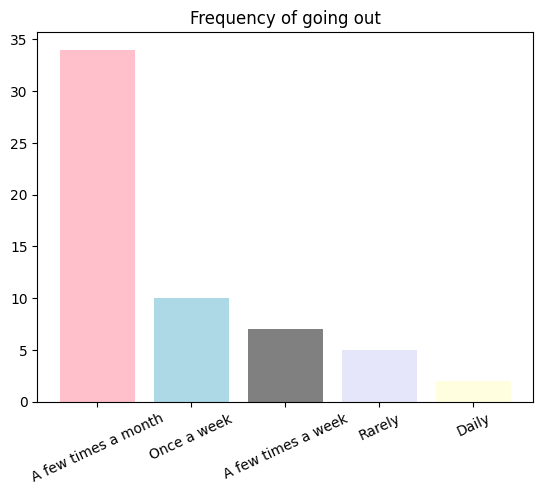

In [25]:
freq=outing_data['how often '].unique()
nums=outing_data['how often '].value_counts()

plt.bar(freq, nums, color=['pink', 'lightblue', 'gray', 'lavender','lightyellow'])

plt.title('Frequency of going out')
plt.xticks(rotation=25)


plt.show()

**Budget vs Enjoyment**

In [26]:
pd.crosstab(outing_data['money_spend'], outing_data['effect'])

effect,Depending on,doesn't affect,enjoy less,enjoy more
money_spend,,,,
1k or more,0,0,0,1
200 or less,0,8,6,0
300-500,1,20,7,5
600-900,1,6,2,1
